# 250605 R - reflections at metal interface 

We want to use the byu book to allow our phase shift code to work at metal interfaces. First we need to figure out 
how the original phase shift code wors. Then we need to Understand how metal interfaces work. recall The ratio of the reflected and transmitted field components to the incident
field components are specified by the Fresnel coefficients (our code denotes these as rperp, tperp, rpara, tpara). Metals do not transmit light. It would be nice if our simultaions would show that tperp and t para are zero for these values but im not sure how they would do that.To expand to include metal surface we need to generalize our refractive index to a complex number $$\tilde{n}=n+jk$$. We are then still able to use our previose fresnel eqaution substituting our complex refractive index. This might cause some issues for our sliders because they were single variable and our new index of refraction is a two variable systen. 

Changes that we are making

1. we made every `ni` -> `ni+1j*ki` and similarly for `nt`
2. we also took out the extra `1j` in front of the `costht` function. we did this because this is not a case of total internal reflection.
3. for R and T, we changed these functions to go from $r^2$ to $r \, r^*$, that is from r-squared to r times it own complex conjugate. similarly for T, we did the same thing, but we did not change the angle portion before that $t^2$ change to $t\, t^*$

What we are still confused about:

1. what is the difference between the two forms of $\cos(\theta_t)$ that we have used? in one form we factor out an imaginary number and in the other form (the original form) we don't. I'm not sure why they seem to give us different numbers.
2. i'm also confused about the amplitude coefficient plot when the incident index is higher than the transmitted index. This should be a case of total internal reflection happening at the critical angle, but i don't understand the plot right now.

In [1]:
%matplotlib widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def funcPlot(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'r--')
    line02, = ax0.plot([],[], 'b--')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((-1,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('amplitude coefficient')
    ax0.legend([r'rperp, r$_s$', r'tperp, t$_s$', r'rpara, r$_p$', r'tpara, t$_p$'],)
    ax0.grid()
    def plot(ni=1, nt=1.5, ki=0, kt=0):
        output1 = func1(ni, nt, ki, kt, thi)
        output2 = func2(ni, nt, ki, kt, thi)
        output3 = func3(ni, nt, ki, kt, thi)
        output4 = func4(ni, nt, ki, kt, thi)
        line01.set_data(thi, output1)
        line02.set_data(thi, output2)
        line03.set_data(thi, output3)
        line04.set_data(thi, output4)
        plt.draw()
    interact(plot, ni=(0,5,.1), nt=(0,5,.1), ki=(0,5,.1), kt=(0,5,.1))

def sin(th):
    return np.sin(th*np.pi/180)

def cos(th):
    return np.cos(th*np.pi/180)

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi

def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))

def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2))
    # return(1j*np.sqrt(((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2-1-0j))
    
def rperp(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    this will provide the reflection coefficient for light 
    perpendicular to the plane of incidence and therefore
    parallel to the interface of the material. 

    this is S-polarized in the nomenclature of optics
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(((ni+1j*ki)/mui*cos_thi-(nt+1j*kt)/mut*cos_tht)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht))

def tperp(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    transmission coefficient for light perpendicular to the 
    plane of incidence and therefore parallel to the interface
    of the material.

    this is S-polarized in the nomenclature of optics
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)

    return((2*(ni+1j*ki)/mui*cos_thi)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht))

def rpara(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    reflection coefficient for light parallel to the 
    plane of incidence.

    this is P-polarized light
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((-(nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))

def tpara(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    '''
    transmission coefficient for light parallel to the 
    plane of incidence.

    this is P-polarized light
    '''
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((2*(ni+1j*ki)/mui*cos_thi)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))

def phasePlot(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'r--')
    line02, = ax0.plot([],[], 'b--')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((-np.pi,np.pi))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('phase shift')
    ax0.legend([r'rperp, r$_s$',r'tperp, t$_s$', r'rpara, r$_p$', r'tpara, t$_p$'],)
    ax0.grid()
    def plot(ni=1, nt=1.5, ki=0, kt=0):
        output1 = phase_shift(func1(ni, nt, ki, kt, thi))
        output2 = phase_shift(func2(ni, nt, ki, kt, thi))
        output3 = phase_shift(func3(ni, nt, ki, kt, thi))
        output4 = phase_shift(func4(ni, nt, ki, kt, thi))
        line01.set_data(thi, output1)
        line02.set_data(thi, output2)
        line03.set_data(thi, output3)
        line04.set_data(thi, output4)
        plt.draw()
    interact(plot, ni=(0,5,.01), nt=(0,5,.01), ki=(0,5,.01), kt=(0,5,.01))

def phase_shift(array):
    return(np.angle(array))

def funcPlot2(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    thi = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'r--')
    line02, = ax0.plot([],[], 'b--')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((0,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('Reflectance and Transmittance')
    ax0.legend([r'Rperp, R$_s$', r'Tperp, T$_s$', r'Rpara, R$_p$', r'Tpara, T$_p$'],)
    ax0.grid()
    def plot(ni=1, nt=1.5, ki=0, kt=0):
        output1 = func1(ni, nt, ki, kt, thi)
        output2 = func2(ni, nt, ki, kt, thi)
        output3 = func3(ni, nt, ki, kt, thi)
        output4 = func4(ni, nt, ki, kt, thi)
        line01.set_data(thi, output1)
        line02.set_data(thi, output2)
        line03.set_data(thi, output3)
        line04.set_data(thi, output4)
        plt.draw()
    interact(plot, ni=(0,5,.01), nt=(0,5,.01), ki=(0,5,.01), kt=(0,5,.01))

def Rperp(ni, nt, ki, kt, thi):
    '''
    reflectance for light 
    perpendicular to the plane of incidence and therefore
    parallel to the interface of the material. 

    this is S-polarized in the nomenclature of optics
    '''
    # return(rperp(ni, nt, ki, kt, thi)**2)
    r = rperp(ni, nt, ki, kt, thi)
    return(r*r.conjugate())

def Rpara(ni, nt, ki, kt, thi):
    '''
    reflectance for light parallel to the 
    plane of incidence.

    this is P-polarized light
    '''
    # return(rpara(ni, nt, ki, kt, thi)**2)
    r = rpara(ni, nt, ki, kt, thi)
    return(r*r.conjugate())

def Tperp(ni, nt, ki, kt, thi):

    cos_tht = costht(ni, nt, ki, kt, thi)
    t = tperp(ni, nt, ki, kt, thi)
    # return(((nt+1j*kt)*cos_tht/(ni+1j*ki)/cos(thi))*tperp(ni, nt, ki, kt, thi)**2)
    return(((nt+1j*kt)*cos_tht/(ni+1j*ki)/cos(thi))*t*t.conjugate())

def Tpara(ni, nt, ki, kt, thi):

    cos_tht = costht(ni, nt, ki, kt, thi)
    t = tpara(ni, nt, ki, kt, thi)
    # return(((nt+1j*kt)*cos_tht/(ni+1j*ki)/cos(thi))*tpara(ni, nt, ki, kt, thi)**2)
    return(((nt+1j*kt)*cos_tht/(ni+1j*ki)/cos(thi))*t*t.conjugate())


interactive(children=(FloatSlider(value=1.0, description='ni', max=5.0), FloatSlider(value=1.5, description='n…

/home/ehreming/anaconda3/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


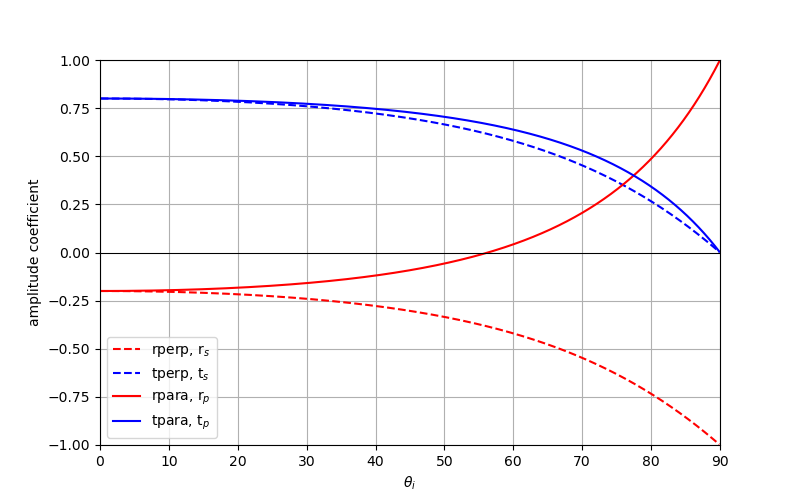

In [3]:
funcPlot(rperp, tperp, rpara, tpara)

interactive(children=(FloatSlider(value=1.0, description='ni', max=5.0, step=0.01), FloatSlider(value=1.5, des…

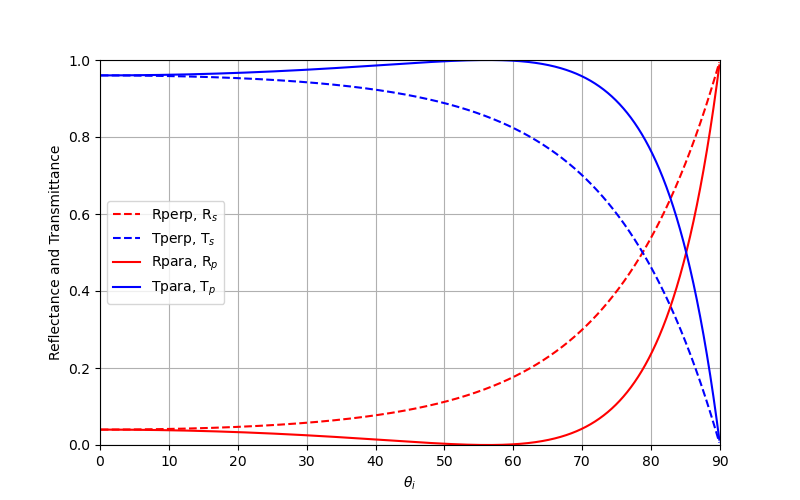

In [4]:
funcPlot2(Rperp, Tperp, Rpara, Tpara)

interactive(children=(FloatSlider(value=1.0, description='ni', max=5.0, step=0.01), FloatSlider(value=1.5, des…

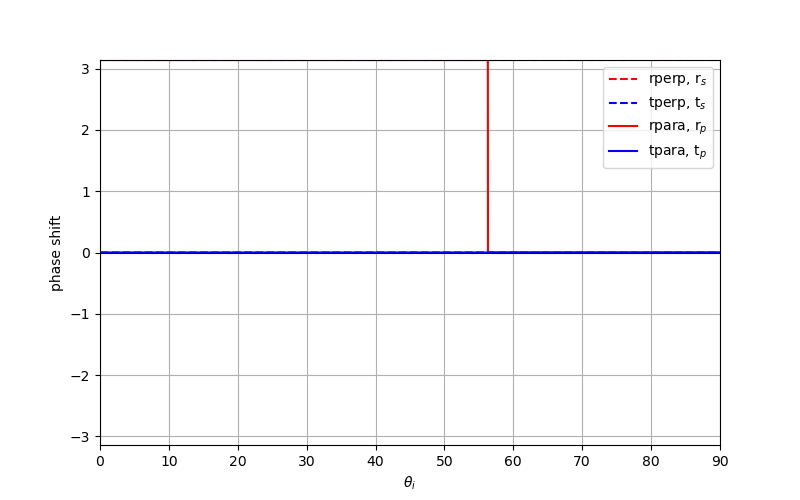

In [5]:
phasePlot(rperp, tperp, rpara, tpara)